In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
input_file = "/data/elugos/event_embedding/train_20251214.csv"
df = pd.read_csv(input_file)

/tmp/ipykernel_2612715/294220121.py:2: DtypeWarning: Columns (40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


In [4]:
df.head()

,index,GlobalEventID,date,Year,Actor1Code,Actor1Name,Actor1CountryCode,Actor1EthnicCode,Actor2Code,Actor2Name,...,target,title,text,description,sbert_text_title,embedding_json_title,sbert_text,embedding_json,first_para,first_para_emb
0,0,1200203233,20240918,2024,USA,UNITED STATES,USA,NaN,CRM,GANG,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164525777101517, -0.027655666694045067, ..."
1,1,1200203234,20240918,2024,USA,FLORIDA,USA,NaN,GOV,ADMINISTRATION,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164525777101517, -0.027655666694045067, ..."
2,2,1200203284,20240925,2024,NaN,NaN,NaN,NaN,CHR,CHRISTIAN,...,brnow,"Yarnell: In times of competing allegiances, re...",NASHVILLE (BP) — The word “tumultuous” is one ...,NASHVILLE (BP) — The word “tumultuous” is one ...,"Yarnell: In times of competing allegiances, re...","[-0.0645490437746048, 0.05730828642845154, 0.0...",NaN,NaN,NASHVILLE (BP) — The word “tumultuous” is one ...,"[0.017953015863895416, -0.06336908042430878, -..."
3,3,1200203520,20240925,2024,NaN,NaN,NaN,NaN,USA,FLORIDA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.018082909286022186, 0.06462761014699936, -..."
4,4,1200203521,20240925,2024,NaN,NaN,NaN,NaN,USA,FLORIDA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.018082909286022186, 0.06462761014699936, -..."


In [5]:
print(df.columns)

Index(['index', 'GlobalEventID', 'date', 'Year', 'Actor1Code', 'Actor1Name',
       'Actor1CountryCode', 'Actor1EthnicCode', 'Actor2Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2EthnicCode', 'IsRootEvent', 'EventCode',
       'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale',
       'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_CountryCode', 'Actor2Geo_CountryCode', 'ActionGeo_Type',
       'ActionGeo_Fullname', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code',
       'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED',
       'SOURCEURL', 'domain', 'target', 'title', 'text', 'description',
       'sbert_text_title', 'embedding_json_title', 'sbert_text',
       'embedding_json', 'first_para', 'first_para_emb'],
      dtype='object')


In [52]:
print(df['EventCode'].value_counts())

EventCode
10      9024
42      8418
43      7905
20      6699
40      6125
        ... 
1244       1
196        1
102        1
813        1
132        1
Name: count, Length: 213, dtype: int64


In [39]:
# Make EventLabel column
# df['EventLabel'] = df['EventCode'].astype(str).str.split("_").str[-1]
df['EventLabel'] = df['EventRootCode']

In [40]:
df['EventLabel'].unique()

array([19,  2, 10,  4,  1, 12,  3,  5,  7,  9, 13, 16, 18, 17, 11, 15,  6,
        8, 14, 20])

Event count:
    Average=5922.55
    Std. dev=6154.896842961708


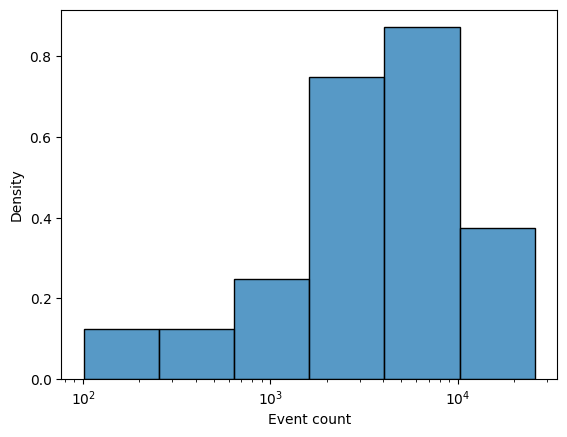

In [43]:
event_counts = df['EventLabel'].value_counts()
sns.histplot(data=event_counts, log_scale=True, stat='density')
plt.xlabel("Event count");

evt_count_avg = event_counts.values.mean()
evt_count_std = event_counts.values.std()
print(f"Event count:")
print(f"    Average={evt_count_avg}")
print(f"    Std. dev={evt_count_std}")


# Event count distribution: log-normal?

In [44]:
cameo_codes = {
    "MAKE PUBLIC STATEMENT": "1",
    "APPEAL": "2",
    "EXPRESS INTENT TO COOPERATE": "3",
    "CONSULT": "4",
    "ENGAGE IN DIPLOMATIC COOPERATION": "5",
    "ENGAGE IN MATERIAL COOPERATION": "6",
    "PROVIDE AID": "7",
    "YIELD": "8",
    "INVESTIGATE": "9",
    "DEMAND": "10",
    "DISAPPROVE": "11",
    "REJECT": "12",
    "THREATEN": "13",
    "PROTEST": "14",
    "EXHIBIT FORCE POSTURE": "15",
    "COERCE": "16",
    "ASSAULT": "17",
    "FIGHT": "19",
    "USE UNCONVENTIONAL MASS VIOLENCE": "20",
}

cameo_code_to_name = {int(v): k for k, v in cameo_codes.items()}
cameo_code_to_name

{1: 'MAKE PUBLIC STATEMENT',
 2: 'APPEAL',
 3: 'EXPRESS INTENT TO COOPERATE',
 4: 'CONSULT',
 5: 'ENGAGE IN DIPLOMATIC COOPERATION',
 6: 'ENGAGE IN MATERIAL COOPERATION',
 7: 'PROVIDE AID',
 8: 'YIELD',
 9: 'INVESTIGATE',
 10: 'DEMAND',
 11: 'DISAPPROVE',
 12: 'REJECT',
 13: 'THREATEN',
 14: 'PROTEST',
 15: 'EXHIBIT FORCE POSTURE',
 16: 'COERCE',
 17: 'ASSAULT',
 19: 'FIGHT',
 20: 'USE UNCONVENTIONAL MASS VIOLENCE'}

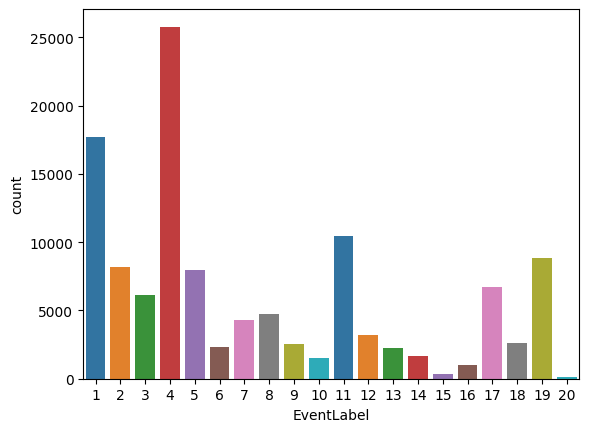

In [51]:
event_count_df = event_counts.reset_index()
sns.barplot(data=event_count_df, x='EventLabel', y='count', hue='EventLabel', palette='tab10', legend=False);
# n_labels = len(evt_filtered)//10
# plt.xticks(range(0, len(evt_filtered), n_labels));


In [ ]:
# Actor1 distribution

print(df['Actor1Code'].value_counts())
print(df['Actor2Code'].value_counts())

Actor1Code
USA          35124
GOV           7449
USAGOV        4089
BUS           3804
JUD           3793
             ...  
TURMIL           1
TTOGOV           1
RUSGOVMIL        1
FRACVL           1
KIR              1
Name: count, Length: 1176, dtype: int64
